# Graficas de frecuencia por feature

Este notebook carga `foot.csv`, excluye la variable objetivo `condition` y genera graficas de frecuencia para cada feature.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [2]:
csv_path = Path("foot.csv")
if not csv_path.exists():
    csv_path = Path("Mundial") / "foot.csv"

df = pd.read_csv(csv_path)
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,condition
0,1,3,1,1,66,228,0,2,0,165,178,2,1.0,1
1,0,3,0,1,59,177,1,1,0,162,140,2,0.0,1
2,0,1,1,0,41,203,1,0,0,132,135,1,0.0,0
3,0,2,0,0,37,215,0,0,0,170,120,0,0.0,0
4,0,0,1,0,64,227,1,0,2,155,170,2,0.6,0


In [3]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   297 non-null    int64  
 1   feature_2   297 non-null    int64  
 2   feature_3   297 non-null    int64  
 3   feature_4   297 non-null    int64  
 4   feature_5   297 non-null    int64  
 5   feature_6   297 non-null    int64  
 6   feature_7   297 non-null    int64  
 7   feature_8   297 non-null    int64  
 8   feature_9   297 non-null    int64  
 9   feature_10  297 non-null    int64  
 10  feature_11  297 non-null    int64  
 11  feature_12  297 non-null    int64  
 12  feature_13  297 non-null    float64
 13  condition   297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,0.144781,2.158249,0.602694,0.326599,54.542088,247.350168,0.676768,0.676768,0.996633,149.599327,131.693603,0.835017,1.055556,0.461279
std,0.352474,0.964859,0.618187,0.469761,9.049736,51.997583,0.468500,0.938965,0.994914,22.941562,17.762806,0.956690,1.166123,0.499340
min,0.000000,0.000000,0.000000,0.000000,29.000000,126.000000,0.000000,0.000000,0.000000,71.000000,94.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,48.000000,211.000000,0.000000,0.000000,0.000000,133.000000,120.000000,0.000000,0.000000,0.000000
50%,0.000000,2.000000,1.000000,0.000000,56.000000,243.000000,1.000000,0.000000,1.000000,153.000000,130.000000,0.000000,0.800000,0.000000
75%,0.000000,3.000000,1.000000,1.000000,61.000000,276.000000,1.000000,1.000000,2.000000,166.000000,140.000000,2.000000,1.600000,1.000000
max,1.000000,3.000000,2.000000,1.000000,77.000000,564.000000,1.000000,3.000000,2.000000,202.000000,200.000000,2.000000,6.200000,1.000000


In [4]:
target = "condition"
features = [column for column in df.columns if column != target]

print(f"Numero de features: {len(features)}")
features

Numero de features: 13


['feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'feature_13']

In [6]:
def plot_feature_frequency(series, feature_name, max_categories=20, bins=15, ax=None):
    current_ax = ax or plt.subplots(figsize=(8, 4.5))[1]
    clean_series = series.dropna()
    unique_count = clean_series.nunique()

    if pd.api.types.is_numeric_dtype(clean_series) and unique_count > max_categories:
        current_ax.hist(clean_series, bins=bins, edgecolor="black", color="#4C78A8")
        current_ax.set_xlabel(feature_name)
        current_ax.set_ylabel("Frecuencia")
    else:
        counts = clean_series.value_counts().sort_index()
        counts.plot(kind="bar", ax=current_ax, color="#59A14F", edgecolor="black")
        current_ax.set_xlabel(feature_name)
        current_ax.set_ylabel("Frecuencia")
        current_ax.tick_params(axis="x", rotation=45)

    current_ax.set_title(f"Frecuencia de {feature_name}")
    current_ax.grid(axis="y", alpha=0.25)
    return current_ax

## Graficas individuales

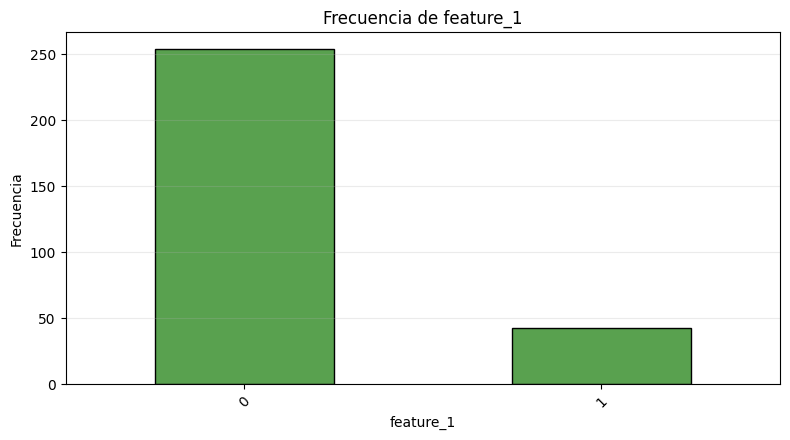

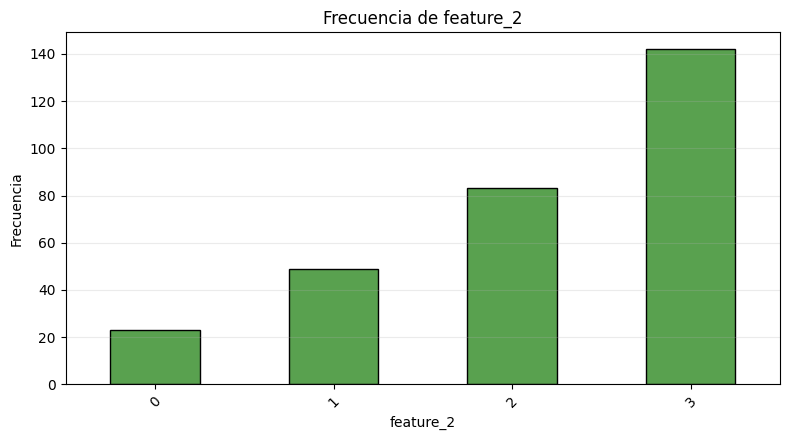

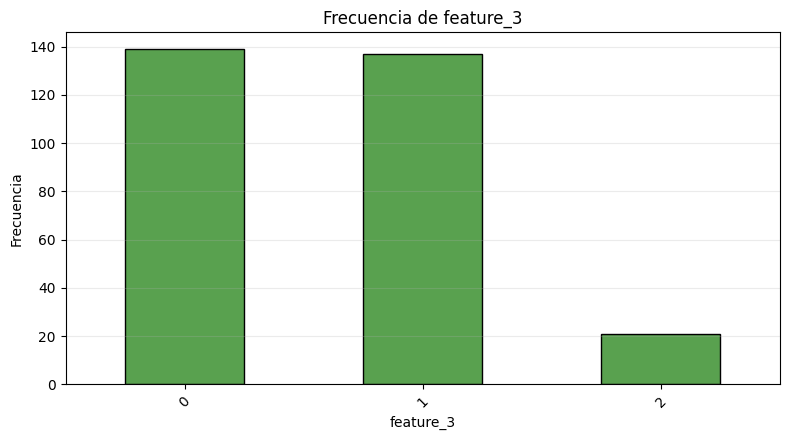

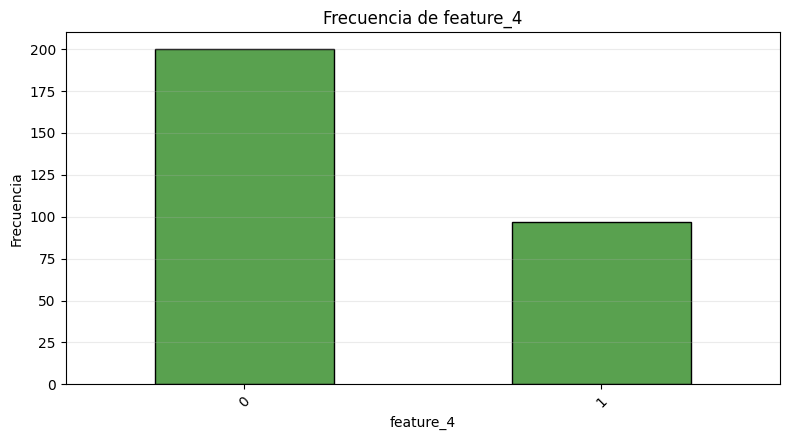

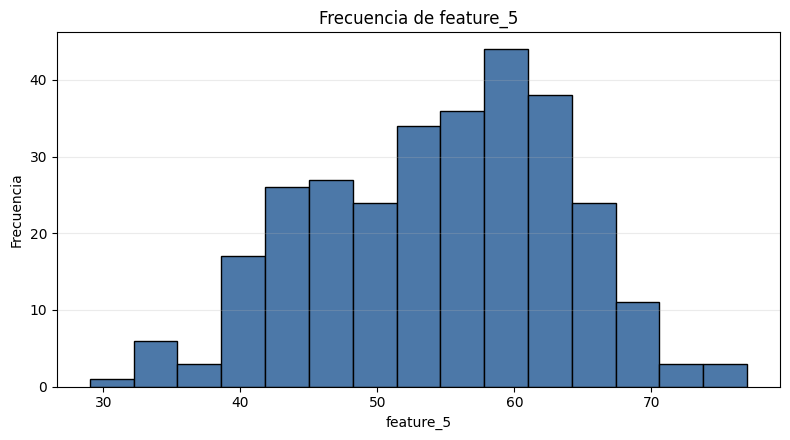

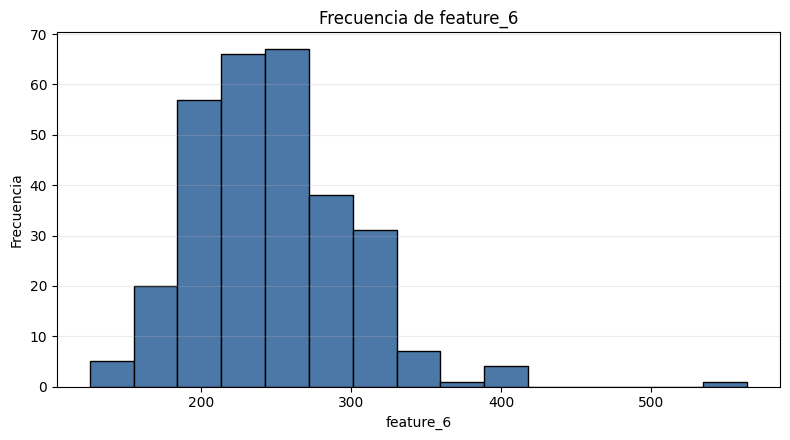

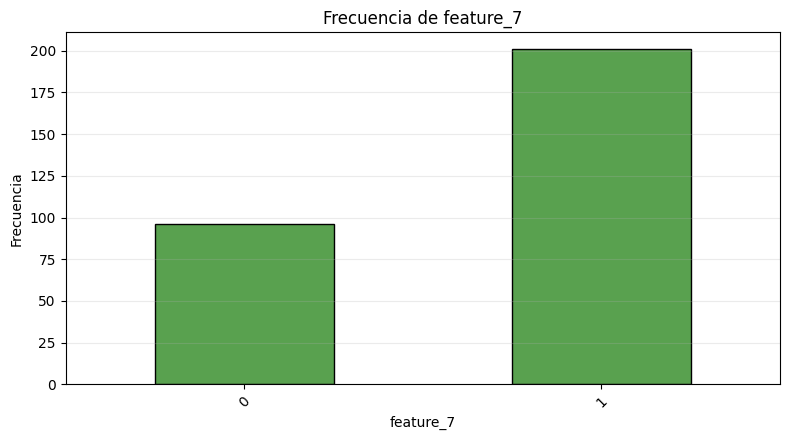

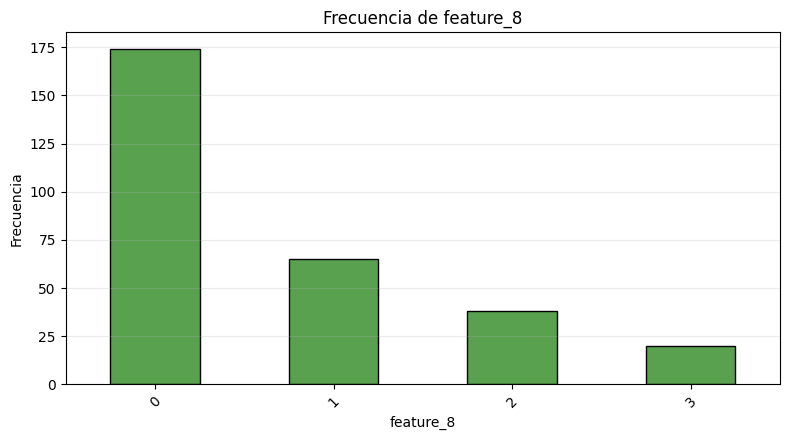

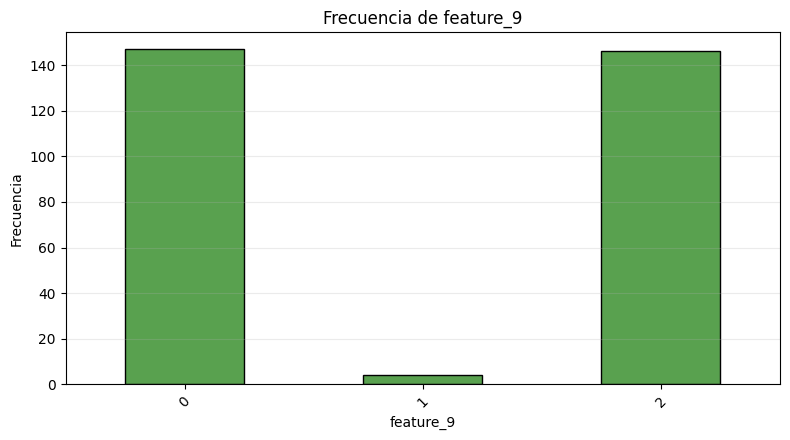

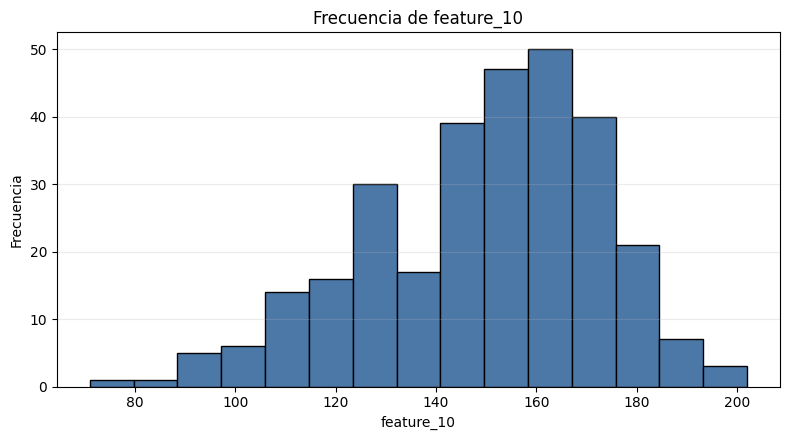

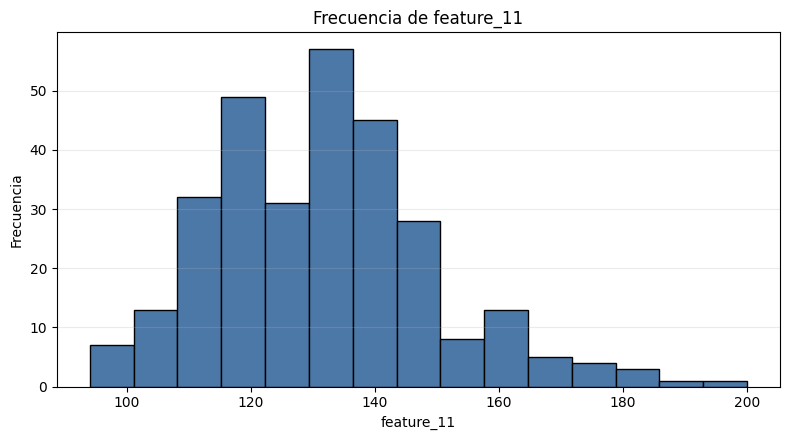

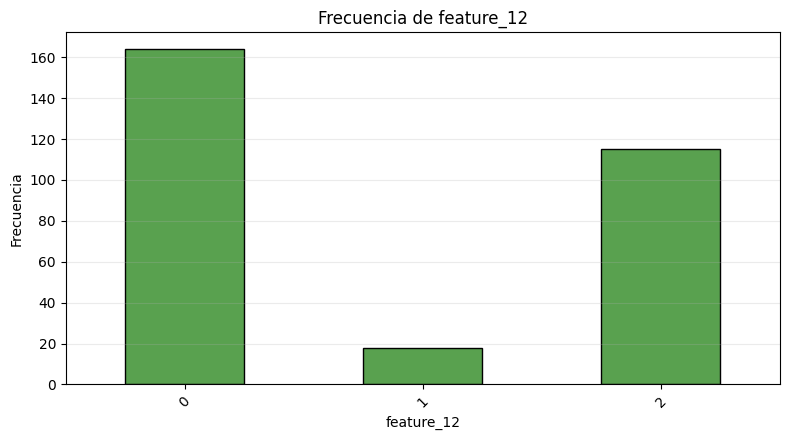

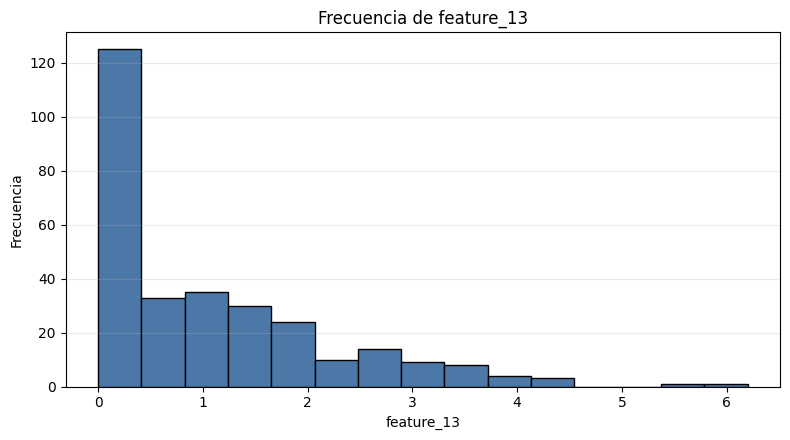

In [7]:
for feature in features:
    plot_feature_frequency(df[feature], feature)
    plt.tight_layout()
    plt.show()

## Grafica combinada

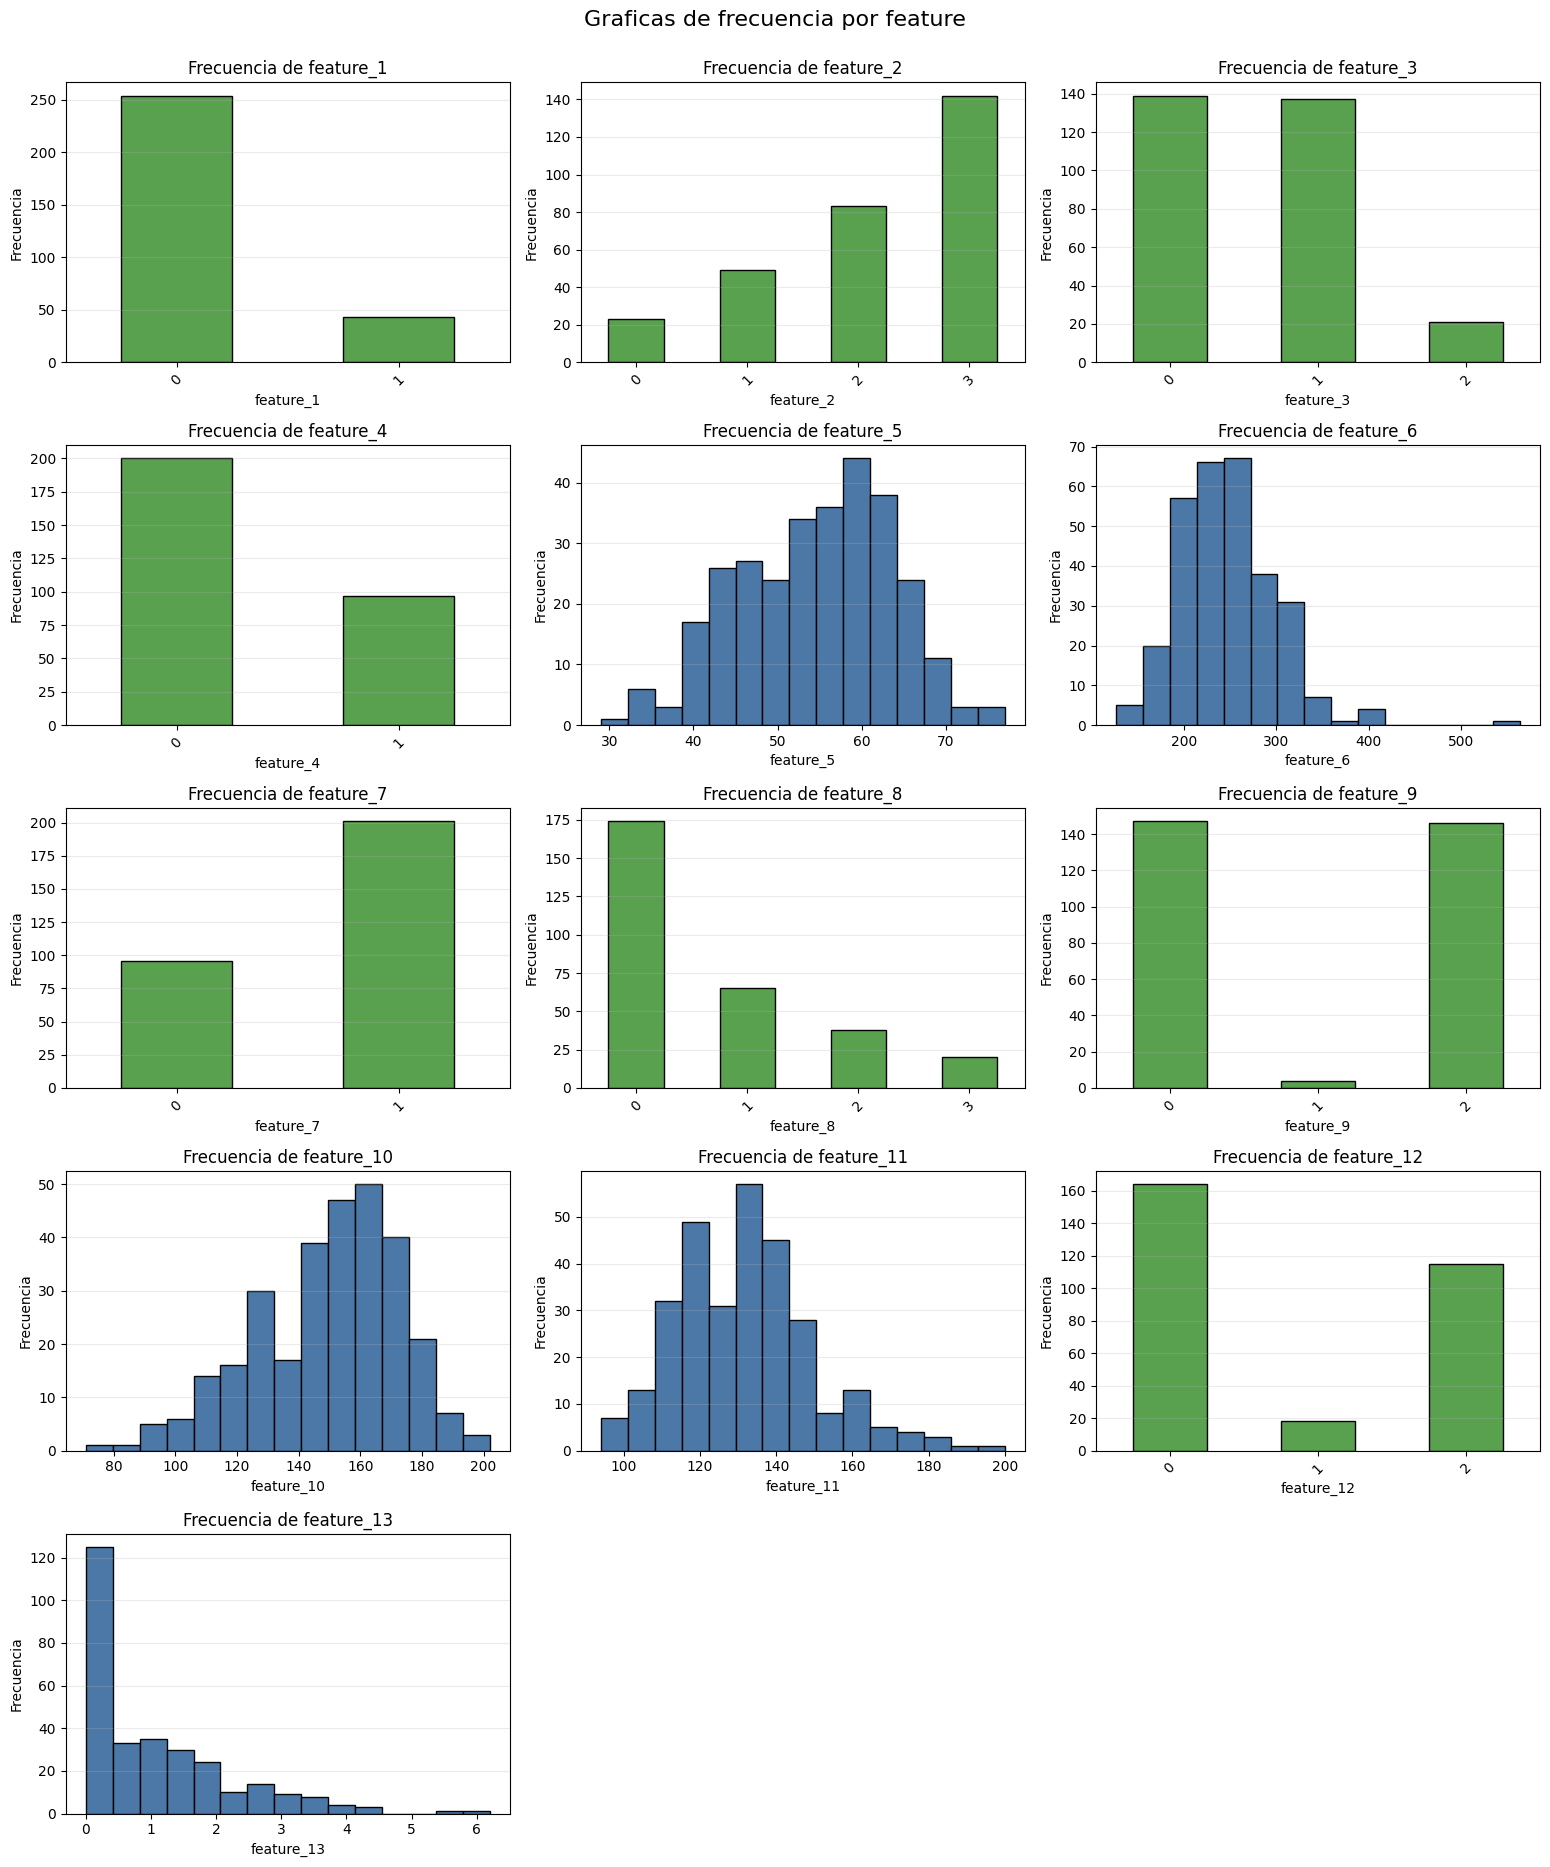

In [9]:
cols = 3
rows = math.ceil(len(features) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.2, rows * 3.8))
flat_axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for ax, feature in zip(flat_axes, features):
    plot_feature_frequency(df[feature], feature, ax=ax)

for ax in flat_axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Graficas de frecuencia por feature", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

## Guardar graficas en PNG

In [10]:
def clean_filename(name):
    valid = [char if char.isalnum() or char in ("-", "_") else "_" for char in name]
    return "".join(valid).strip("_") or "feature"

output_dir = Path("graficas_frecuencia")
output_dir.mkdir(parents=True, exist_ok=True)

for feature in features:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_feature_frequency(df[feature], feature, ax=ax)
    fig.tight_layout()
    fig.savefig(output_dir / f"{clean_filename(feature)}_frecuencia.png", dpi=160)
    plt.close(fig)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.2, rows * 3.8))
flat_axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for ax, feature in zip(flat_axes, features):
    plot_feature_frequency(df[feature], feature, ax=ax)

for ax in flat_axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Graficas de frecuencia por feature", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.savefig(output_dir / "todas_las_frecuencias.png", dpi=180)
plt.close(fig)

print(f"Graficas guardadas en: {output_dir.resolve()}")

Graficas guardadas en: E:\University\4to\ML\Mundial\graficas_frecuencia
